In [8]:
import numpy as np
"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""

# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
# (5 points)
# TODO: Create the matrix described above
# Hint: Use np.ones and array slicing
my_matrix = np.ones((5, 5))
my_matrix[1:-1, 1:-1] = 0 # slice by setting all the cells who are not on the border and set to zero
print("Task 1: 5x5 Matrix")
print(my_matrix)

# Task 2: Normalize a random array
# (5 points)
np.random.seed(42)
random_data = np.random.randn(100, 3)
# TODO: Normalize each column to have mean=0 and std=1
normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)
print("Task 2: Normalised Matrix")
print(normalized)

# Task 3: Implement linear regression solution using normal equation
# (10 points)
# Given X (features) and y (target), compute theta
# theta = (X^T X)^(-1) X^T y
print("Linear Regression")
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
# TODO: Calculate theta_hat using the normal equation
theta_hat = np.linalg.inv(((X.T) @ X)) @ (X.T @ y)
# TODO: Print the estimated coefficients and compare with true_theta 
print("Estimated theta:", theta_hat)
print("True theta:     ", true_theta)
print("Absolute error: ", np.abs(theta_hat - true_theta))

Task 1: 5x5 Matrix
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
Task 2: Normalised Matrix
[[ 4.93439239e-01  4.61603061e-02  5.17340053e-01]
 [ 1.74402998e+00 -5.22690072e-02 -2.79011884e-01]
 [ 1.81249029e+00  9.75852610e-01 -4.91538532e-01]
 [ 5.49303576e-01 -2.87606868e-01 -4.88156860e-01]
 [ 1.83017852e-01 -1.77587837e+00 -1.62529439e+00]
 [-7.96980164e-01 -8.51575049e-01  2.16218628e-01]
 [-1.21826859e+00 -1.26163023e+00  1.25601706e+00]
 [-3.86933017e-01  2.57404552e-01 -1.35421958e+00]
 [-7.75162723e-01  3.01948517e-01 -1.10699945e+00]
 [ 3.45978124e-01 -4.28463047e-01 -3.30989813e-01]
 [-8.45013279e-01  2.08943513e+00 -7.97583137e-02]
 [-1.40066567e+00  1.03242274e+00 -1.17007910e+00]
 [ 1.42686307e-01 -1.82349718e+00 -1.26701701e+00]
 [ 1.28061139e-01  9.46117052e-01  8.71885533e-02]
 [-2.52739338e-01 -1.20992939e-01 -1.40278120e+00]
 [-9.88966824e-01 -2.84754328e-01  8.87088163e-01]
 [ 3.06888192e-01 -1.62165820e+00  2.25101819e-0

In [29]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration (10 points)
print("Task 1: Data Cleaning and Exploration")
# TODO: Display basic information about the dataset
print("\nDataset Info: \n", df.info())
# TODO: Identify and count missing values
print("\nNumber of missing values \n", df.isnull().sum())
# TODO: Fill missing exam_score with the mean score for the student's major
df['exam_score'] = df['exam_score'].fillna(df['exam_score'].mean())
# TODO: Fill missing hours_studied with the median for the student's year
df['hours_studied'] = df['hours_studied'].fillna(df['hours_studied'].median())
print("\nNew cleaned dataframe: ", df)

# Task 2: Analysis (10 points)
print("")
print("Task 2: Analysis")
# TODO: Calculate and display the average exam_score by major
print("\nThe average exam_score by major: \n", df.groupby('major')['exam_score'].mean())
# TODO: Find the major with the highest average exam_score
print("\nThe major with the highest average exam_score: \n", df.groupby('major')['exam_score'].mean().nlargest(1))
# TODO: Calculate the correlation between hours_studied and exam_score
print("\nThe correlation between hours_studied and exam_score:\n", df['hours_studied'].corr(df['exam_score']))
# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
df['performance'] = df['exam_score'].apply(lambda x: 'Excellent' if x > 90 else ('Good' if x >= 80 else ('Average' if x >= 70 else 'Needs Improvement')))
print("\nGeneral Performances:\n", df['performance'])

# Task 3: Advanced Analysis (10 points)
print("")
print("Task 3: Advanced Analysis")
# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
print("\nNumber of students by year/major\n", df.groupby(['major', 'year'])['exam_score'].count())
print("\nAverage exam score by year/major\n", df.groupby(['major', 'year'])['exam_score'].mean())
print("\nAverage study hours by year/major\n", df.groupby(['major', 'year'])['hours_studied'].mean())
# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
print("\nTop 5 Performing Students\n", df.nlargest(5, 'exam_score', keep='all'))
# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)
pivot_df = df.pivot_table(values='exam_score', index='major', columns='year', aggfunc='mean')
print("\nPivot Table\n", pivot_df)

Task 1: Data Cleaning and Exploration
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 9.5 KB

Dataset Info: 
 None

Number of missing values 
 student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64

New cleaned dataframe:       student_id    major  year  exam_score  assignments_completed  \
0          1000  Physics     3   68.199753                     10   
1

Task 1: Distribution Visualization


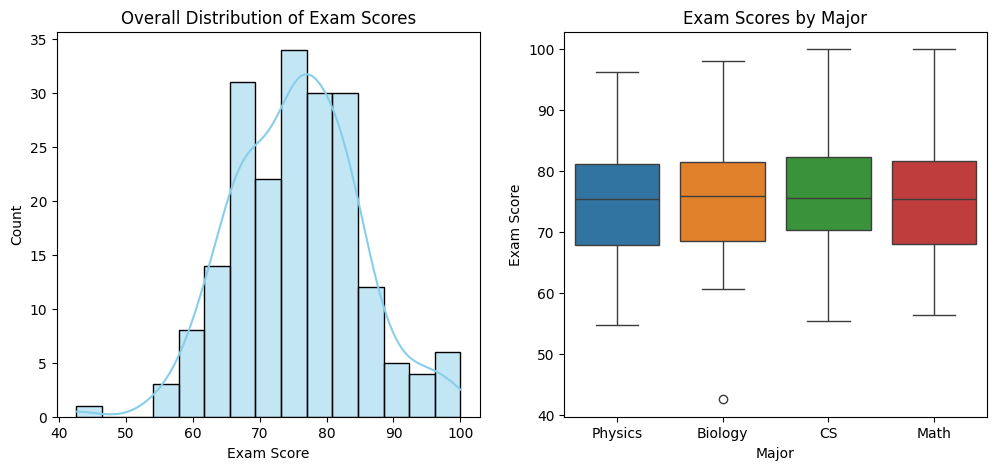

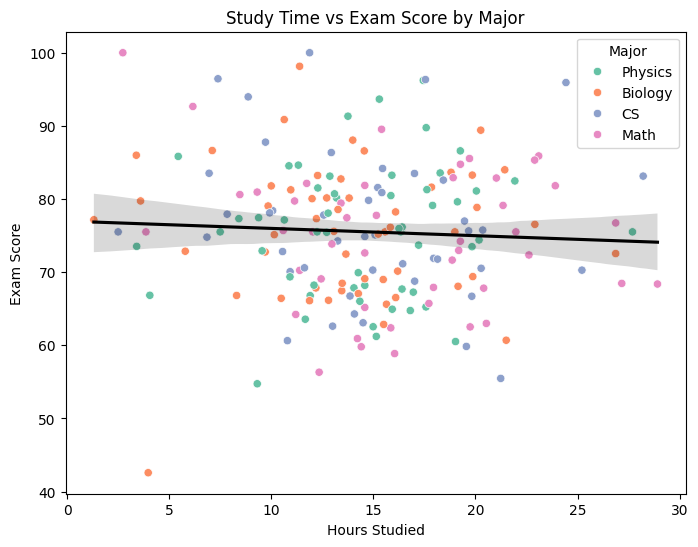

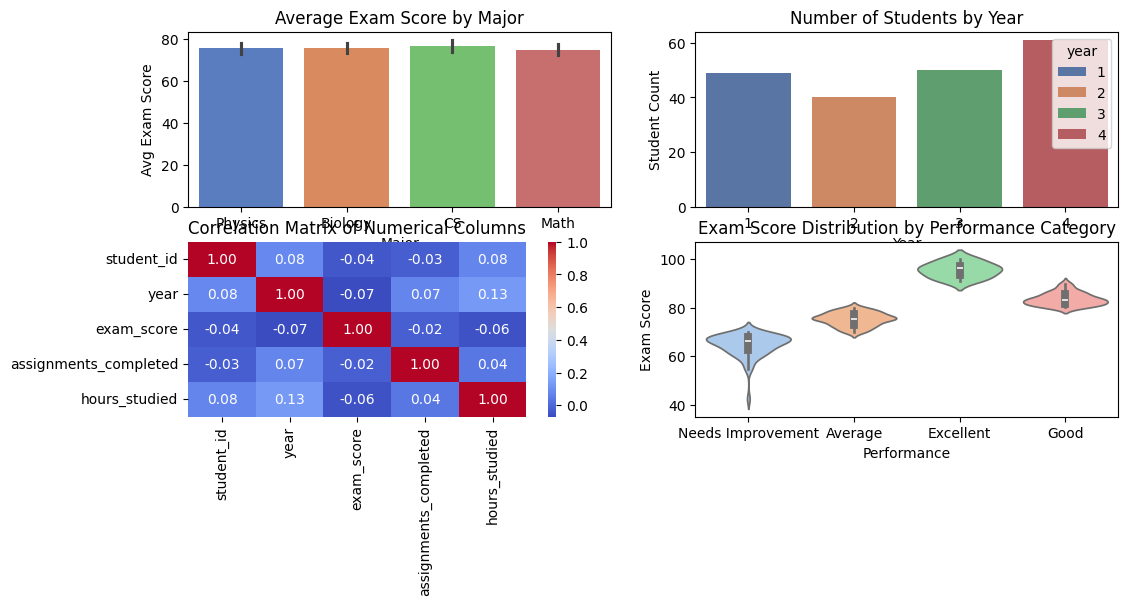

In [40]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns

# Continue using the df from Exercise 5

# Task 1: Distribution Visualization (8 points)
print("Task 1: Distribution Visualization")
# TODO: Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
#       Right: Box plot of exam scores by major
# TODO: Add appropriate titles, labels, and styling
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
# Plot Left
sns.histplot(data=df, x='exam_score', kde=True, color='skyblue', bins=15, ax=axes[0])
axes[0].set_title('Overall Distribution of Exam Scores')
axes[0].set_xlabel('Exam Score')

# Plot Right
sns.boxplot(data=df, x='major', y='exam_score', ax=axes[1], hue='major', legend=False)
axes[1].set_title('Exam Scores by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Exam Score')

# Task 2: Relationship Visualization (8 points)
# TODO: Create a scatter plot of hours_studied vs exam_score
# TODO: Color points by major
# TODO: Add a regression line
# TODO: Include appropriate legends, titles, and axis 
fig2, axes2 = plt.subplots(figsize=(8, 6))

sns.scatterplot(data=df, x="hours_studied", y="exam_score", hue="major", ax=axes2, palette="Set2")
sns.regplot(data=df, x="hours_studied", y="exam_score", scatter=False, ax=axes2, color="black")
axes2.set_title("Study Time vs Exam Score by Major")
axes2.set_xlabel("Hours Studied")
axes2.set_ylabel("Exam Score")
axes2.legend(title="Major") 

# Task 3: Advanced Dashboard (9 points)
# TODO: Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
#       2. Count plot: Number of students by year
#       3. Heat map: Correlation matrix of numerical columns
#       4. Violin plot: Exam score distribution by performance category
# TODO: Adjust layout, add titles, and ensure readability
fig3, axes3 = plt.subplots(nrows=2, ncols=2, figsize=(12, 5))

# Bar Chart
sns.barplot(data=df, x="major", y="exam_score", ax=axes3[0, 0], hue="major", palette="muted")
axes3[0, 0].set_title("Average Exam Score by Major")
axes3[0, 0].set_xlabel("Major")
axes3[0, 0].set_ylabel("Avg Exam Score")

# Count Plot
sns.countplot(data=df, x="year", ax=axes3[0, 1], hue="year", palette="deep") 
axes3[0, 1].set_title("Number of Students by Year")
axes3[0, 1].set_xlabel("Year")
axes3[0, 1].set_ylabel("Student Count")

# Heat Map
numerical_cols = df.select_dtypes(include=["number"]) # only numbers
corr_matrix = numerical_cols.corr()

sns.heatmap(data=corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=axes3[1, 0])
axes3[1, 0].set_title("Correlation Matrix of Numerical Columns")

# Violin Plot
sns.violinplot(data=df, x="performance", y="exam_score", ax=axes3[1, 1], hue="performance", palette="pastel")
axes3[1, 1].set_title("Exam Score Distribution by Performance Category")
axes3[1, 1].set_xlabel("Performance")
axes3[1, 1].set_ylabel("Exam Score")

plt.show()


Number of customers by age group:
 age_group
18-25     81
26-35     73
36-50    160
51-70    186
Name: age, dtype: int64

Average income by age group:
 age_group
18-25    50634.018330
26-35    48747.148046
36-50    48516.895668
51-70    50713.163384
Name: income, dtype: float64

Average CLV by age group:
 age_group
18-25    718.371170
26-35    747.738562
36-50    732.796612
51-70    762.693498
Name: CLV, dtype: float64

Total CLV by age group:
 age_group
18-25     58188.064760
26-35     54584.915035
36-50    117247.457917
51-70    141860.990683
Name: CLV, dtype: float64

Top 10% cut-off point: $1222.94
Number of VIP customers: 50


Text(0.5, 1.0, 'Feature Correlation Matrix')

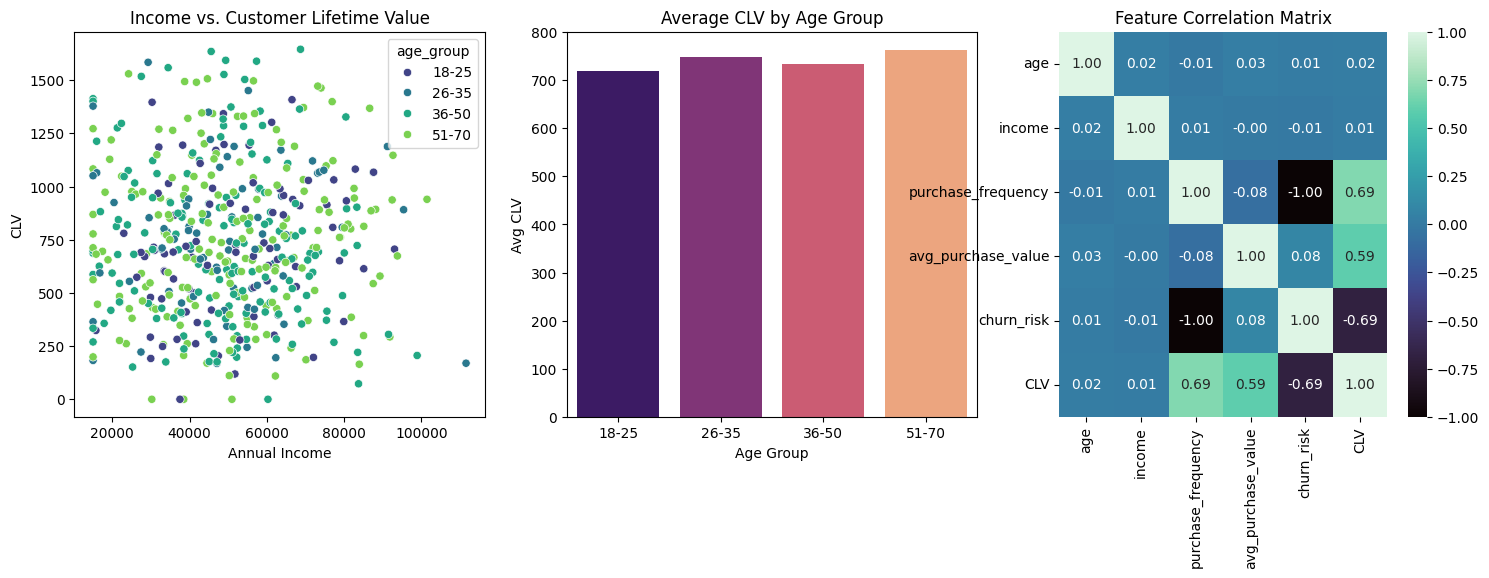

In [43]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# TODO: Calculate customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency

max_freq = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_freq)

customers['CLV'] = (customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk']))

# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70
age_bins = [17, 25, 35, 50, 70]
age_labels = ['18-25', '26-35', '36-50', '51-70']

customers['age_group'] = pd.cut(customers['age'], bins=age_bins, labels=age_labels)

# TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total 

print("\nNumber of customers by age group:\n", 
      customers.groupby('age_group', observed=False)['age'].count())

print("\nAverage income by age group:\n", 
      customers.groupby('age_group', observed=False)['income'].mean())

print("\nAverage CLV by age group:\n", 
      customers.groupby('age_group', observed=False)['CLV'].mean())

print("\nTotal CLV by age group:\n", 
      customers.groupby('age_group', observed=False)['CLV'].sum())

# TODO: Identify top 10% of customers by CLV
clv_90th_percentile = customers['CLV'].quantile(0.90)
top_10_percent_customers = customers[customers['CLV'] >= clv_90th_percentile]

print(f"\nTop 10% cut-off point: ${clv_90th_percentile:.2f}")
print(f"Number of VIP customers: {len(top_10_percent_customers)}")

# TODO: Create visualizations:
#       1. Scatter plot of income vs CLV (color by age group)
#       2. Bar chart of average CLV by age group
#       3. Correlation heatmap

# Scatter Plot
fig7, axes7 = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
sns.scatterplot(data=customers, x="income", y="CLV", hue="age_group", ax=axes7[0],  palette="viridis")
axes7[0].set_title("Income vs. Customer Lifetime Value")
axes7[0].set_xlabel("Annual Income")
axes7[0].set_ylabel("CLV")

# Bar Chart
sns.barplot(data=age_summary.reset_index(), x="age_group", y="avg_CLV", hue="age_group", dodge=False, legend=False, ax=axes7[1], palette="magma")
axes7[1].set_title("Average CLV by Age Group")
axes7[1].set_xlabel("Age Group")
axes7[1].set_ylabel("Avg CLV")

# Correlation HeatMap
numerical_features = customers.select_dtypes(include=["number"])
corr_features = numerical_features.corr()

sns.heatmap(data=corr_features, annot=True, cmap="mako", fmt=".2f", ax=axes7[2])
axes7[2].set_title("Feature Correlation Matrix")

# TODO: Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations